# 02 - Demand Model

The brief requires the environment's dynamics to be **estimated from the historical data**
rather than assumed. This notebook fits every primitive the simulator needs:

| primitive | what it controls | method |
|---|---|---|
| cancellation probability | how much booked revenue is actually realised | gradient boosting |
| reference rate, season volume | price level and market size | medians / counts |
| booking curve | when demand arrives | lead-time histogram |
| **price elasticity** | how demand responds to our rate | willingness-to-pay curve |
| **market regimes** | external demand shocks | tercile Markov chain |
| competitor index | rival's rate | cross-property ratio |

Everything is written to `results/demand_tables.joblib`, which the environment loads.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from plotting import use_style, save_fig, colour
use_style()

import joblib
from config import DATA_PROCESSED, RESULTS, FEATURE_COLS, CAT_COLS, MULTIPLIERS
import demand

df = pd.read_csv(DATA_PROCESSED / "clean.csv")
print(f"{len(df):,} cleaned bookings")

116,962 cleaned bookings


## 1. Cancellation model

A booking that cancels earns nothing, so the reward function discounts revenue by
`P(cancel)`. `HistGradientBoostingClassifier` is used because the strongest predictors
(`country`, `deposit_type`, `market_segment`) are high-cardinality categoricals that it
handles natively, and because it is fast enough to refit in seconds.

In [2]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split

X = df[FEATURE_COLS].copy()
y = df["is_canceled"]
for c in CAT_COLS:
    X[c] = X[c].astype("category")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

cancel_model = HistGradientBoostingClassifier(
    categorical_features="from_dtype", learning_rate=0.1, max_iter=300,
    l2_regularization=1.0, random_state=42)
cancel_model.fit(X_train, y_train)
print(f"train {X_train.shape}   test {X_test.shape}")

train (93569, 22)   test (23393, 22)


In [3]:
from sklearn.metrics import (average_precision_score, classification_report,
                             confusion_matrix, roc_auc_score)

proba = cancel_model.predict_proba(X_test)[:, 1]
print(f"ROC-AUC {roc_auc_score(y_test, proba):.4f}   "
      f"PR-AUC {average_precision_score(y_test, proba):.4f}")
print(classification_report(y_test, proba >= 0.5, digits=3))
print("confusion matrix:\n", confusion_matrix(y_test, proba >= 0.5))

ROC-AUC 0.9361   PR-AUC 0.9119
              precision    recall  f1-score   support

           0      0.870     0.907     0.888     14602
           1      0.835     0.775     0.804      8791

    accuracy                          0.858     23393
   macro avg      0.852     0.841     0.846     23393
weighted avg      0.857     0.858     0.857     23393

confusion matrix:
 [[13251  1351]
 [ 1977  6814]]


Discrimination is only half the requirement: the reward function multiplies revenue by
this probability, so it must be **calibrated**, not merely ranked correctly. The
calibration curve tracks the diagonal closely, so the predicted probabilities can be used
as-is.

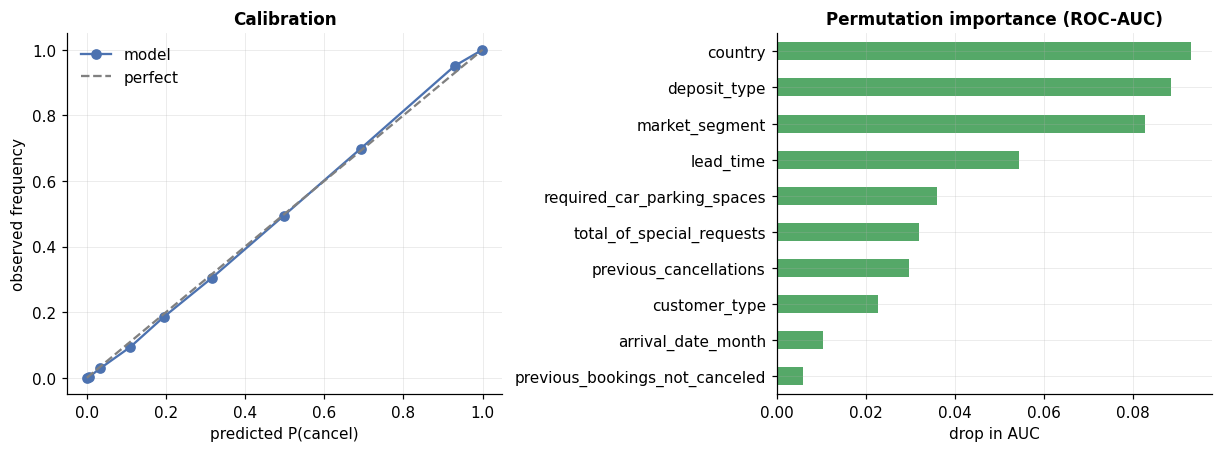

In [4]:
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy="quantile")
imp = permutation_importance(cancel_model, X_test.iloc[:5000], y_test.iloc[:5000],
                             n_repeats=5, random_state=42, scoring="roc_auc")
importances = pd.Series(imp.importances_mean, index=FEATURE_COLS).nlargest(10)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(mean_pred, frac_pos, "o-", color="#4c72b0", label="model")
axes[0].plot([0, 1], [0, 1], "--", color="grey", label="perfect")
axes[0].set(title="Calibration", xlabel="predicted P(cancel)", ylabel="observed frequency")
axes[0].legend()
importances.sort_values().plot(kind="barh", ax=axes[1], color="#55a868")
axes[1].set(title="Permutation importance (ROC-AUC)", xlabel="drop in AUC")
save_fig("02_cancellation_model")
plt.show()

## 2. Price elasticity - and why the obvious estimator fails

The natural approach is to regress log bookings on log rate. It gives the **wrong sign**:

In [5]:
ref_price, demand_vol, timing = demand.reference_tables(df)
reg = demand.naive_price_regression(df, ref_price)

print(f"own-price   beta = {reg['own_beta']:+.3f}  95% CI {reg['own_ci']}  p = {reg['own_p']:.4f}")
print(f"cross-price beta = {reg['cross_beta']:+.3f}  95% CI {reg['cross_ci']}  p = {reg['cross_p']:.4f}")
print(f"n = {reg['n_obs']},  R2 = {reg['r2']:.3f}")

own-price   beta = +0.699  95% CI (np.float64(0.125), np.float64(1.273))  p = 0.0172
cross-price beta = +0.244  95% CI (np.float64(-0.36), np.float64(0.848))  p = 0.4275
n = 272,  R2 = 0.340


A **positive** own-price coefficient would mean guests buy more as rates rise. This is
textbook simultaneity: hotels raise rates precisely when demand is strong, so the
regression traces out the intersection of shifting demand and supply curves rather than
the demand curve itself. Without an instrument the coefficient is not identified.

The revenue-management alternative is to read the price response off the **willingness-to-pay
curve**. The share of historical bookings transacted at or above a rate is a
non-parametric estimate of `S(p) = P(WTP >= p)` - the fraction of the market that would
still book at that rate. Fitting a constant-elasticity form to `S` across the action grid
gives an elasticity per (hotel, month).

*Two caveats, stated plainly.* First, observed rate dispersion partly reflects product mix
(room type, board basis, segment) rather than pure price sensitivity, so this estimator
likely **overstates** elasticity just as the regression understates it. The two bracket the
truth, and notebook 07 sweeps elasticity from 1.5 to 4.0 to show the conclusions survive
either way.

Second, the constant-elasticity form is only an approximation. The plot below shows it
tracking the data closely from list price upward (shaded), which is where every optimal
policy in this study operates, but **overshooting below list price** - it predicts more than
the whole market would book at a 30% discount. Deep discounting is therefore modelled
optimistically, which if anything understates how much the learned policies gain by *not*
discounting.

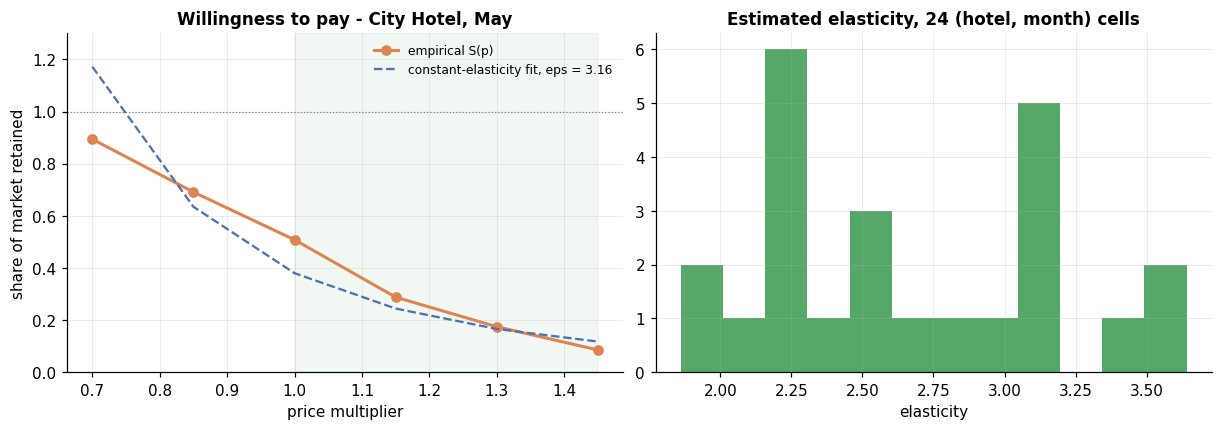

elasticity: mean 2.67, range 1.86 to 3.64


In [6]:
elasticity = demand.elasticity_table(df, ref_price)
eps_city_may, survival, fitted = demand.wtp_elasticity(
    df.query("hotel == 'City Hotel' and arrival_date_month == 'May'")["adr"].to_numpy(),
    float(ref_price.loc["May", "City Hotel"]))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(MULTIPLIERS, survival, "o-", color="#dd8452", lw=2, label="empirical S(p)")
axes[0].plot(MULTIPLIERS, fitted, "--", color="#4c72b0",
             label=f"constant-elasticity fit, eps = {eps_city_may:.2f}")
axes[0].axhline(1.0, color="grey", lw=0.8, ls=":")
axes[0].axvspan(1.0, MULTIPLIERS.max(), color="#55a868", alpha=0.08)
axes[0].set(title="Willingness to pay - City Hotel, May", xlabel="price multiplier",
            ylabel="share of market retained", ylim=(0, 1.3))
axes[0].legend(fontsize=8)

axes[1].hist(elasticity.to_numpy().ravel(), bins=12, color="#55a868")
axes[1].set(title="Estimated elasticity, 24 (hotel, month) cells", xlabel="elasticity")
save_fig("02_elasticity")
plt.show()

print(f"elasticity: mean {elasticity.to_numpy().mean():.2f}, "
      f"range {elasticity.to_numpy().min():.2f} to {elasticity.to_numpy().max():.2f}")

## 3. Market regimes - the external-factor state variable

Weekly booking volume divided by its across-year average for the same calendar week
removes seasonality and leaves a pure demand *shock*. Cutting the shock into terciles gives
three market regimes, and counting consecutive weeks gives the transition matrix.

The diagonal dominates, so regimes **persist**: a soft week is more likely than not
followed by another soft week. That persistence is what makes the regime worth observing -
it carries information about the weeks ahead.

In [7]:
regime = demand.market_regimes(df)
pi = demand.stationary_distribution(regime["transition"])

print("demand factors (soft / normal / strong):", np.round(regime["factors"], 3))
print("stationary distribution              :", np.round(pi, 3))
print("\ntransition matrix:")
print(pd.DataFrame(regime["transition"].round(3),
                   index=["soft", "normal", "strong"],
                   columns=["soft", "normal", "strong"]).to_string())

demand factors (soft / normal / strong): [0.769 1.006 1.225]
stationary distribution              : [0.326 0.339 0.335]

transition matrix:
         soft  normal  strong
soft    0.562   0.342   0.096
normal  0.368   0.342   0.289
strong  0.053   0.333   0.613


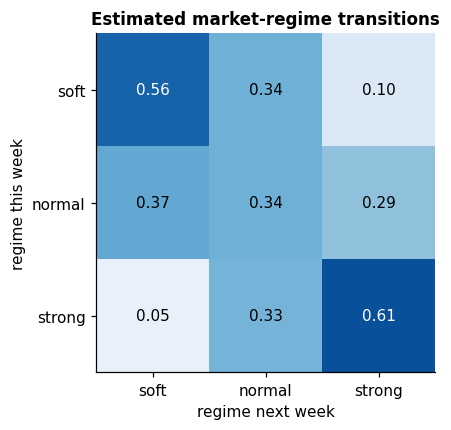

In [8]:
fig, ax = plt.subplots(figsize=(4.6, 3.8))
im = ax.imshow(regime["transition"], cmap="Blues", vmin=0, vmax=0.7)
ax.set(xticks=range(3), yticks=range(3),
       xticklabels=["soft", "normal", "strong"], yticklabels=["soft", "normal", "strong"],
       xlabel="regime next week", ylabel="regime this week",
       title="Estimated market-regime transitions")
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{regime['transition'][i, j]:.2f}", ha="center", va="center",
                color="white" if regime["transition"][i, j] > 0.4 else "black")
ax.grid(False)
save_fig("02_regime_transitions")
plt.show()

## 4. Reference rates, season volume and the competitor index

With two properties in the dataset, each serves as the other's competitor. The index is
the rival's reference rate relative to ours; above 1 means the rival is priced above us.
Its effect on our demand is the cross-price coefficient estimated above - positive, as
expected for substitutes, but weakly identified, so it is applied as a modest shifter.

In [9]:
competitor = demand.competitor_index(ref_price)
summary = pd.concat({
    "ref price": ref_price.round(0),
    "bookings/yr": demand_vol.round(0),
    "elasticity": elasticity.round(2),
    "competitor idx": competitor.round(2),
}, axis=1)
summary

ref price              bookings/yr               \
hotel              City Hotel Resort Hotel  City Hotel Resort Hotel   
arrival_date_month                                                    
January                  80.0         48.0      1224.0        692.0   
February                 80.0         53.0      1625.0        998.0   
March                    88.0         56.0      2123.0       1073.0   
April                   105.0         76.0      2469.0       1169.0   
May                     120.0         74.0      2707.0       1159.0   
June                    118.0        106.0      2605.0        997.0   
July                    107.0        153.0      2660.0       1493.0   
August                  110.0        189.0      2954.0       1609.0   
September               108.0         87.0      2427.0       1009.0   
October                 100.0         58.0      2484.0       1137.0   
November                 86.0         46.0      1421.0        779.0   
December                 86.0         60.0      1336.0        835.0   

                   elasticity              competitor idx               
hotel              City Hotel Resort Hotel     City Hotel Resort Hotel  
arrival_date_month                                                      
January                  3.51         2.60           0.60         1.67  
February                 3.18         2.30           0.66         1.51  
March                    3.14         2.16           0.63         1.58  
April                    3.00         2.56           0.72         1.38  
May                      3.16         2.27           0.62         1.61  
June                     3.64         2.09           0.90         1.12  
July                     2.54         2.62           1.43         0.70  
August                   2.25         3.41           1.72         0.58  
September                2.27         1.86           0.80         1.24  
October                  3.13         2.34           0.58         1.72  
November                 3.19         2.21           0.54         1.86  
December                 2.88         1.86           0.70         1.43

In [10]:
tables = demand.build_demand_tables(df)
RESULTS.mkdir(parents=True, exist_ok=True)
joblib.dump(tables, RESULTS / "demand_tables.joblib")
joblib.dump(cancel_model, RESULTS / "cancel_model.joblib")
print("saved:", ", ".join(sorted(tables)))

saved: competitor, demand_vol, elasticity, price_regression, ref_price, regime, timing
